# Olist Ecommerce Sales Analysis – Python

## 1. Project Overview
**Description:**  
This Python stage of the project builds on the SQL analysis. We explore revenue trends, customer behavior, seller performance, product insights, delivery efficiency, and regional revenue patterns using **Pandas**, **Matplotlib**, and **Seaborn**. The goal is to practice Python analytics while generating actionable insights.

## 2. Data Loading & Inspection
**Description:**  
Load data from the database using `psycopg2` or `SQLAlchemy`. Inspect dataframes, check column types, missing values, duplicates, and basic statistics.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, inspect
import squarify
from matplotlib.ticker import FuncFormatter, MultipleLocator, ScalarFormatter
from deep_translator import GoogleTranslator
import time
from collections import Counter
from nltk.sentiment import SentimentIntensityAnalyzer

In [7]:
username = "root"
password = "abelytics"
database = "olist_ecommerce_db"
host = "127.0.0.1:3306"

In [8]:
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}/{database}")
connection = engine.connect()
print("Connected successfully!")

Connected successfully!


###

## 🧠 1. Get Inspector (Core Tool)
👉`Inspector` is the **database explorer**

### 1. Get all tables

In [9]:
inspector = inspect(engine)
tables = inspector.get_table_names()
print(tables)

['customers', 'geolocation', 'order_items', 'order_payments', 'order_reviews', 'orders', 'product_category_name_translation', 'products', 'rfm_base', 'rfm_recency', 'rfm_scores', 'rfm_table', 'sellers']


### 2. Get all views

In [10]:
views = inspector.get_view_names()
print(views)

['vw_customer_summary', 'vw_revenue_by_state']


### 3.Get Columns for Each Table

In [6]:
# for table in inspector.get_table_names():
#     print(f"\nTable: {table}")
    
#     columns = inspector.get_columns(table)
    
#     for col in columns:
#         print(f"  {col['name']} ({col['type']})")

### 4.Get Primary Keys

In [7]:
# for table in inspector.get_table_names():
#     pk = inspector.get_pk_constraint(table)
#     print(f"{table} PK:", pk["constrained_columns"])

### 5.Get Foreign Keys (Relationships 🔥)

In [8]:
# for table in inspector.get_table_names():
#     fks = inspector.get_foreign_keys(table)
    
#     print(f"\n{table} Foreign Keys:")
#     for fk in fks:
#         print(f"  {fk['constrained_columns']} → {fk['referred_table']}.{fk['referred_columns']}")

### 6. Get Indexes

In [9]:
# for table in inspector.get_table_names():
#     indexes = inspector.get_indexes(table)
#     print(f"{table} Indexes:", indexes)

### 7. Get Table Schema (Database Structure)

In [11]:
schemas = inspector.get_schema_names()
print(schemas)

['amazon_product_reviews', 'globomart', 'information_schema', 'kms_inventory', 'md_water_services', 'mysql', 'olist_ecommerce_db', 'performance_schema', 'sakila', 'salesdb', 'sys']


### 8. Get View Definition (SQL Behind View)

In [11]:
# for view in inspector.get_view_names():
#     definition = inspector.get_view_definition(view)
#     print(f"\nView: {view}")
#     print(definition)

### 8. Get Indexes

In [12]:
# for table in inspector.get_table_names():
#     indexes = inspector.get_indexes(table)
#     print(f"{table} Indexes:", indexes)

### 10. FULL DATABASE OVERVIEW SCRIPT

In [13]:
# print("SCHEMAS:", inspector.get_schema_names())

# print("\nTABLES:", inspector.get_table_names())

# print("\nVIEWS:", inspector.get_view_names())

# for table in inspector.get_table_names():
#     print(f"\n========== {table} ==========")
    
#     # Columns
#     for col in inspector.get_columns(table):
#         print(f"{col['name']} - {col['type']}")
    
#     # Primary Key
#     pk = inspector.get_pk_constraint(table)
#     print("PK:", pk["constrained_columns"])
    
#     # Foreign Keys
#     for fk in inspector.get_foreign_keys(table):
#         print("FK:", fk["constrained_columns"], "→", fk["referred_table"])

# 🧠 SQL EQUIVALENT (Very Important for You)

| What you want | SQL                          |
| ------------- | ---------------------------- |
| Tables        | `SHOW TABLES`                |
| Views         | `SHOW VIEWS`                 |
| Columns       | `DESCRIBE table`             |
| Relationships | `INFORMATION_SCHEMA`         |
| Metadata      | `INFORMATION_SCHEMA.COLUMNS` |

---

###

In [15]:
tables = [
    "customers",
    "sellers",
    "products",
    "orders",
    "order_items",
    "order_payments",
    "order_reviews",
    "geolocation",
    "product_category_name_translation",
    "rfm_table"
    ]

In [16]:
db = {}

for table in tables:
    print(f"Loading {table}...")
    db[table] = pd.read_sql(f"SELECT * FROM {table}", engine)

Loading customers...
Loading sellers...
Loading products...
Loading orders...
Loading order_items...
Loading order_payments...
Loading order_reviews...
Loading geolocation...
Loading product_category_name_translation...
Loading rfm_table...


In [17]:
customers = db["customers"]
products = db["products"]
orders = db["orders"]
order_items = db["order_items"]
order_reviews = db["order_reviews"]
order_payments = db["order_payments"]
sellers = db["sellers"]
geolocation = db["geolocation"]
pcnt = db["product_category_name_translation"]
rfm = db["rfm_table"]

### Null Check

In [17]:
# for table in tables:
#     print("==================================")
#     print(f"========={table.upper()}=========")
#     print("==================================")
#     print(db[table].isnull().sum())
#     print("\n")

### Duplicate Check

In [18]:
# for table in tables:
#     print("==================================")
#     print(f"========={table.upper()}=========")
#     print("==================================")
#     print(db[table].duplicated().sum())
#     print("\n")

In [19]:
# for table in tables:
#     print("==================================")
#     print(f"========={table.upper()}=========")
#     print("==================================")
#     print(db[table].dtypes)
#     print("\n")

### Delivered Orders

### Merged Orders

In [18]:
merged_orders = pd.merge(
    orders,
    order_items,
    on="order_id",
    how="inner")

merged_orders.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93


In [19]:
merged_orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
order_item_id                             int64
product_id                               object
seller_id                                object
shipping_limit_date              datetime64[ns]
price                                   float64
freight_value                           float64
dtype: object

### Total Revenue

In [22]:
total_revenue = merged_orders["price"].sum().round()
total_revenue

13591644.0

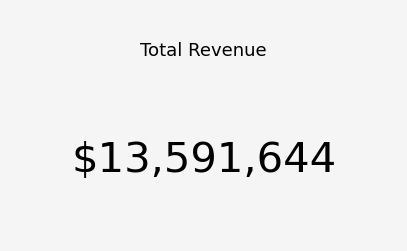

In [30]:
fig, ax = plt.subplots(figsize=(5,3))
fig.patch.set_facecolor('#f5f5f5')

ax.text(0.5, 0.8, "Total Revenue", fontsize=13, ha='center')
ax.text(0.5, 0.3, f"${total_revenue:,.0f}", fontsize=30, ha='center')

ax.axis("off")
plt.show()

##
## 3. Monthly Revenue Trend
**Description:**  
Analyze revenue over months and years. Preprocessing includes creating `year`, `month`, `month_name`, `day`, `day_name`, and `hour` from delivery timestamp. Sorting months chronologically ensures correct visualization.

### Extract Date Parts

In [80]:
merged_orders["year"] = merged_orders["order_purchase_timestamp"].dt.year
merged_orders["month"] = merged_orders["order_purchase_timestamp"].dt.month
merged_orders["month_name"] = merged_orders["order_purchase_timestamp"].dt.month_name()
merged_orders["month_year"] = merged_orders["order_purchase_timestamp"].dt.strftime('%b-%Y')
merged_orders["day_name"] = merged_orders["order_purchase_timestamp"].dt.day_name()
merged_orders["hour"] = merged_orders["order_purchase_timestamp"].dt.hour

merged_orders["year"] = merged_orders["year"].astype("int64")
merged_orders["month"] = merged_orders["month"].astype("int64")

###

### Monthly Revenue

In [82]:
monthly_revenue = (
    merged_orders
    .groupby(["year", "month", "month_name", "month_year"])["price"]
    .sum()
    .round()
    .reset_index()
    .sort_values(["year", "month"])
)

monthly_revenue

,year,month,month_name,month_year,price
0,2016,9,September,Sep-2016,267.0
1,2016,10,October,Oct-2016,49508.0
2,2016,12,December,Dec-2016,11.0
3,2017,1,January,Jan-2017,120313.0
4,2017,2,February,Feb-2017,247303.0
5,2017,3,March,Mar-2017,374344.0
6,2017,4,April,Apr-2017,359927.0
7,2017,5,May,May-2017,506071.0
8,2017,6,June,Jun-2017,433039.0
9,2017,7,July,Jul-2017,498031.0


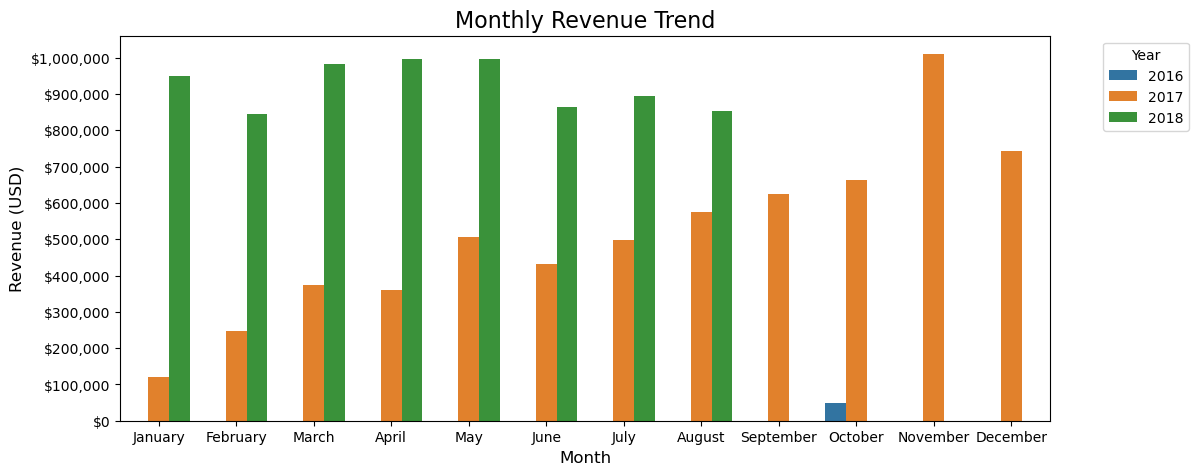

In [62]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

fig, ax = plt.subplots(figsize=(12, 5))

# Plot
sns.barplot(
    x="month_name",
    y="price",
    hue="year",
    data=monthly_revenue,
    order=month_order,
    ax=ax
)

# Set y-axis ticks every 1000 (locator)
ax.yaxis.set_major_locator(MultipleLocator(100000))

ax.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")

# Format y-axis labels as currency with thousands separator (formatter)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax.set_title("Monthly Revenue Trend", fontsize=16)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Revenue (USD)", fontsize=12)

plt.show()

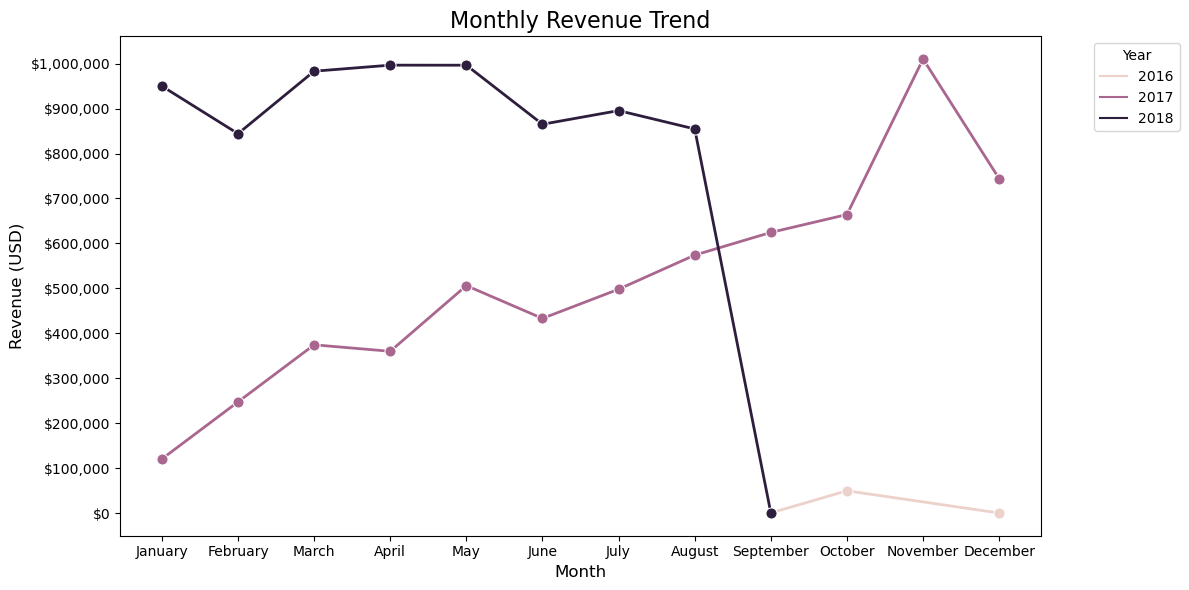

In [101]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Convert month_name into ordered categorical
monthly_revenue["month_name"] = pd.Categorical(
    monthly_revenue["month_name"],
    categories=month_order,
    ordered=True
)

# Sort values properly
monthly_revenue = monthly_revenue.sort_values(["year", "month_name"])


fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    x="month_name",
    y="price",
    hue="year",
    data=monthly_revenue,
    marker="o",
    linewidth=2,
    markersize=8,
    ax=ax
)

# Revenue formatting
ax.yaxis.set_major_locator(MultipleLocator(100000))

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# Labels and title
ax.set_title("Monthly Revenue Trend", fontsize=16)

ax.set_xlabel("Month", fontsize=12)

ax.set_ylabel("Revenue (USD)", fontsize=12)

# Legend
ax.legend(
    title="Year",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

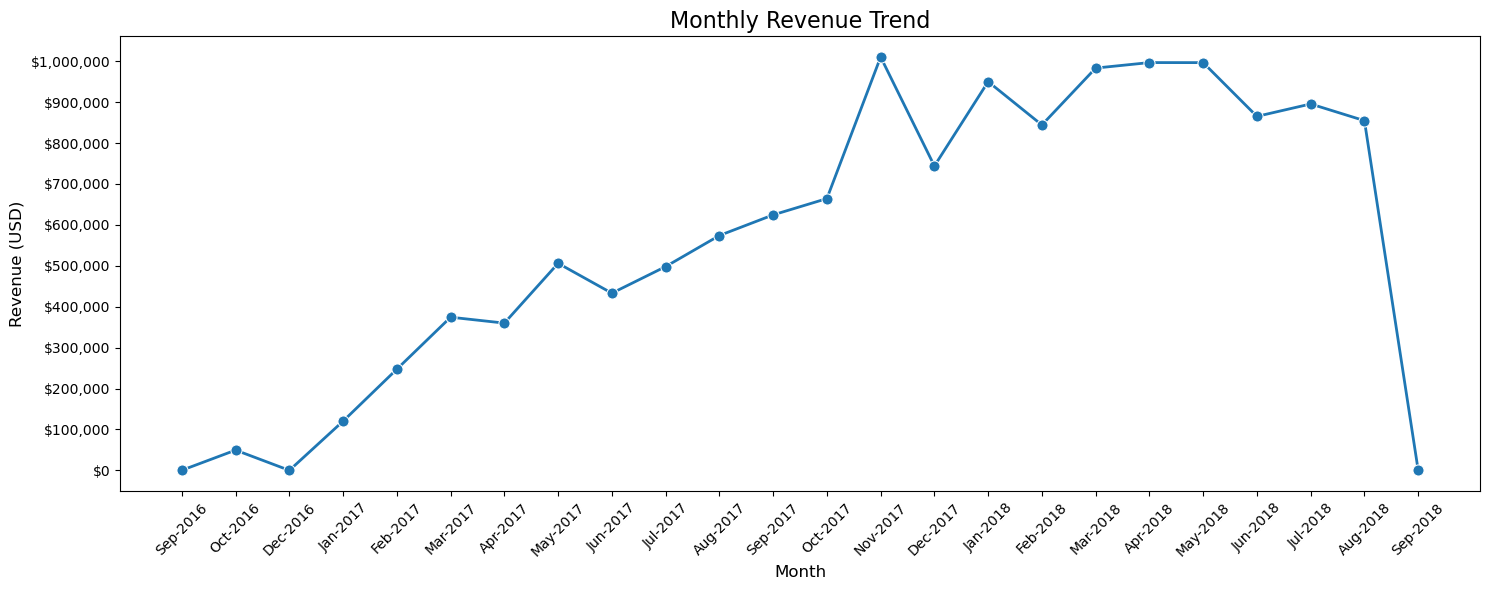

In [103]:
fig, ax = plt.subplots(figsize=(15, 6))

sns.lineplot(
    x="month_year",
    y="price",
    data=monthly_revenue,
    marker="o",
    markersize=8,
    linewidth=2,
    ax=ax
)

# Revenue formatting
ax.yaxis.set_major_locator(MultipleLocator(100000))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Labels and title
ax.set_title("Monthly Revenue Trend", fontsize=16)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Revenue (USD)", fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

###

### Total Customer

In [70]:
total_customers  = customers["customer_unique_id"].nunique()

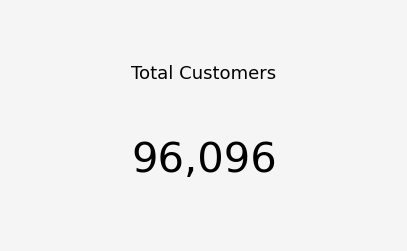

In [72]:
fig, ax = plt.subplots(figsize=(5,3))
fig.patch.set_facecolor('#f5f5f5')

ax.text(0.5, 0.7, "Total Customers", fontsize=13, ha='center')
ax.text(0.5, 0.3, f"{total_customers:,.0f}", fontsize=30, ha='center')

ax.axis("off")
plt.show()

###

### Customer status and revenue summary

In [73]:
# merge customers with merged orders
customer_orders = merged_orders.merge(customers, on="customer_id")
# customer_orders.info()

In [32]:
# Determine customer status

customer_summary = (
    customer_orders
    .groupby("customer_unique_id")
    .agg(
        total_orders=("order_id", "count"),
        total_revenue=("price", "sum")
    )
    .reset_index()
)

# Add 'One Time' or 'Repeat' label
customer_summary["customer_status"] = customer_summary["total_orders"].apply(
    lambda x: "One Time" if x == 1 else "Repeat"
)

# Summarize by customer status
customer_status_summary = (
    customer_summary
    .groupby("customer_status")
    .agg(
        total_orders=("total_orders", "sum"),
        total_revenue=("total_revenue", "sum")
    )
    .reset_index()
)

# Calculate revenue percentage
customer_status_summary["revenue_percentage"] = (
    customer_status_summary["total_revenue"] / customer_status_summary["total_revenue"].sum() * 100
).round(2)

customer_status_summary

,customer_status,total_orders,total_revenue,revenue_percentage
0,One Time,81748,10698374.21,80.92
1,Repeat,28449,2523123.90,19.08


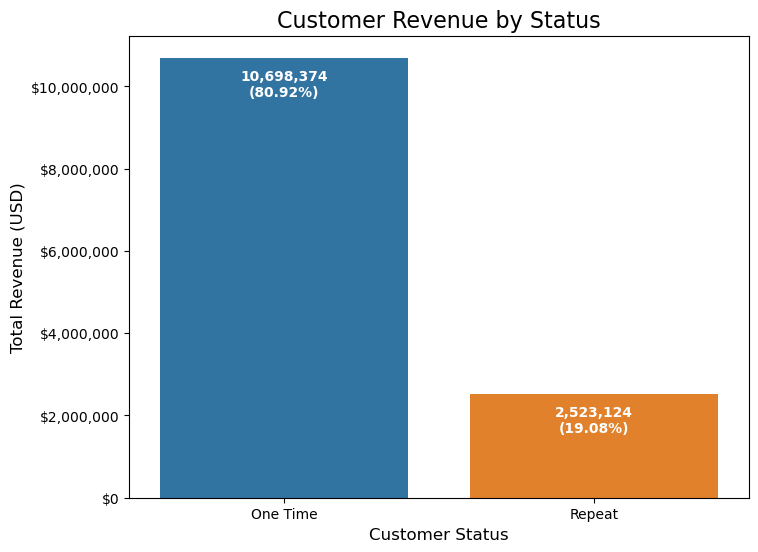

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    x="customer_status",
    y="total_revenue",
    data=customer_status_summary,
    ax=ax
)


# Add labels INSIDE the bar (top position)
for container in ax.containers:
    labels = [
        f'{rev:,.0f}\n({pct}%)'
        for rev, pct in zip(
            customer_status_summary["total_revenue"],
            customer_status_summary["revenue_percentage"]
        )
    ] 
    ax.bar_label(
        container,
        labels=labels,
        label_type='edge',   # positions at top edge of bar
        padding= -30,         # 🔥 pushes label inside the bar
        color='white',       # white text
        fontsize=10,
        fontweight='bold'
    )

# Format y-axis as currency
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Titles and labels
ax.set_title("Customer Revenue by Status", fontsize=16)
ax.set_xlabel("Customer Status", fontsize=12)
ax.set_ylabel("Total Revenue (USD)", fontsize=12)

plt.show()

### Customer Revenue by Status

**Objective:**  
To analyze how revenue is distributed between one-time and repeat customers.

**Methodology:**  
- Grouped data by `customer_unique_id` to calculate total orders and revenue.
- Classified customers into:
  - One Time (1 order)
  - Repeat (more than 1 order)
- Aggregated revenue by customer status.
- Visualized using a bar chart with revenue and percentage labels.

**Key Insights:**  
- One-time customers contribute 80.92% of total revenue.
- Repeat customers contribute only 19.08%.
- Revenue is heavily dependent on new customers.

**Interpretation:**  
- The business has strong acquisition but weak retention.
- Most customers do not return after their first purchase.
- There is a significant opportunity to improve customer lifetime value.

**Visualization Notes:**  
- Labels inside bars show both revenue and percentage contribution.
- Y-axis is formatted in USD with thousands separator for readability.
- Color palette and layout are kept consistent for clarity.

In [34]:
customer_summary

,customer_unique_id,total_orders,total_revenue,customer_status
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,One Time
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,One Time
2,0000f46a3911fa3c0805444483337064,1,69.00,One Time
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,One Time
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,One Time
...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,2,1570.00,Repeat
93354,fffea47cd6d3cc0a88bd621562a9d061,1,64.89,One Time
93355,ffff371b4d645b6ecea244b27531430a,1,89.90,One Time
93356,ffff5962728ec6157033ef9805bacc48,1,115.00,One Time


In [35]:
customer_status_summary

,customer_status,total_orders,total_revenue,revenue_percentage
0,One Time,81748,10698374.21,80.92
1,Repeat,28449,2523123.90,19.08


### Customer Order Summary (AOV)

In [36]:
customer_status_summary["avg_order_value"] = (
    customer_status_summary["total_revenue"] /
    customer_status_summary["total_orders"]
).round()
customer_status_summary

,customer_status,total_orders,total_revenue,revenue_percentage,avg_order_value
0,One Time,81748,10698374.21,80.92,131.0
1,Repeat,28449,2523123.90,19.08,89.0


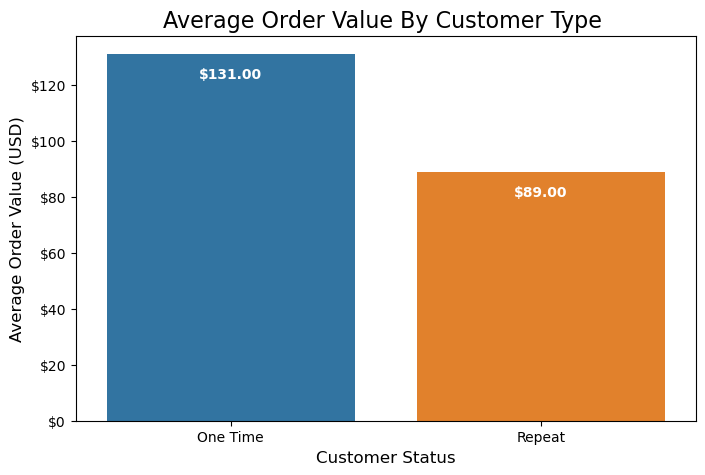

In [37]:
fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(
    data=customer_status_summary,
    x="customer_status",
    y="avg_order_value",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in customer_status_summary["avg_order_value"]],
        padding=-20,
        color="white",
        fontweight="bold"
    )

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax.set_title("Average Order Value By Customer Type ", fontsize=16)
ax.set_ylabel("Average Order Value (USD)", fontsize=12)
ax.set_xlabel("Customer Status", fontsize=12)

plt.show()

### Average Order Value (AOV) Analysis

**Objective:**  
To evaluate customer spending behavior by comparing average order value between one-time and repeat customers.

**Methodology:**  
- Calculated total orders and total revenue for each customer group.
- Computed Average Order Value (AOV) as:
  - AOV = Total Revenue / Total Orders
- Compared metrics across customer segments.

**Key Insights:**  
- One-time customers have a higher AOV ($131) than repeat customers ($89).
- One-time customers account for 80.92% of total revenue.
- Repeat customers contribute only 19.08% of revenue.

**Interpretation:**  
- Customers tend to make higher-value purchases initially but do not return frequently.
- Repeat customers generate lower revenue per transaction, indicating weaker engagement.
- This suggests a gap in customer retention and long-term value creation.

**Business Implications:**  
- The business relies heavily on new customer acquisition for revenue growth.
- Improving customer retention could significantly increase overall revenue.
- There is a need to enhance post-purchase engagement and customer experience.

**Visualization Notes:**  
- Bar chart compares AOV across customer types.
- Labels inside bars display formatted currency values.
- Consistent styling is applied for readability and comparison.

In [38]:
# customer_status_summary.drop(columns=["average_order_value"], inplace=True)

### Product by Revenue

In [39]:
product_summary = (
    merged_orders
    .groupby("product_id")
    .agg(
        total_orders=("product_id", "count"),
        total_revenue=("price", "sum")
    )
    .reset_index()
)
product_summary

,product_id,total_orders,total_revenue
0,00066f42aeeb9f3007548bb9d3f33c38,1,101.65
1,00088930e925c41fd95ebfe695fd2655,1,129.90
2,0009406fd7479715e4bef61dd91f2462,1,229.00
3,000b8f95fcb9e0096488278317764d19,2,117.80
4,000d9be29b5207b54e86aa1b1ac54872,1,199.00
...,...,...,...
32211,fff6177642830a9a94a0f2cba5e476d1,2,229.98
32212,fff81cc3158d2725c0655ab9ba0f712c,1,90.00
32213,fff9553ac224cec9d15d49f5a263411f,1,32.00
32214,fffdb2d0ec8d6a61f0a0a0db3f25b441,5,169.95


In [40]:
top_products_revenue = (
    product_summary
    .sort_values(by="total_revenue", ascending=False)
    .head(10)
)
top_products_revenue

,product_id,total_orders,total_revenue
23546,bb50f2e236e5eea0100680137654686c,194,63560.00
13749,6cdd53843498f92890544667809f1595,153,53652.30
26997,d6160fb7873f184099d9bc95e30376af,33,45949.35
26436,d1c427060a0f73f6b889a5c7c61f2ac4,332,45620.56
19290,99a4788cb24856965c36a24e339b6058,477,42049.66
7881,3dd2a17168ec895c781a9191c1e95ad7,272,40782.80
4892,25c38557cf793876c5abdd5931f922db,38,38907.32
12074,5f504b3a1c75b73d6151be81eb05bdc9,63,37733.90
10616,53b36df67ebb7c41585e8d54d6772e08,321,37454.63
21617,aca2eb7d00ea1a7b8ebd4e68314663af,520,37104.30


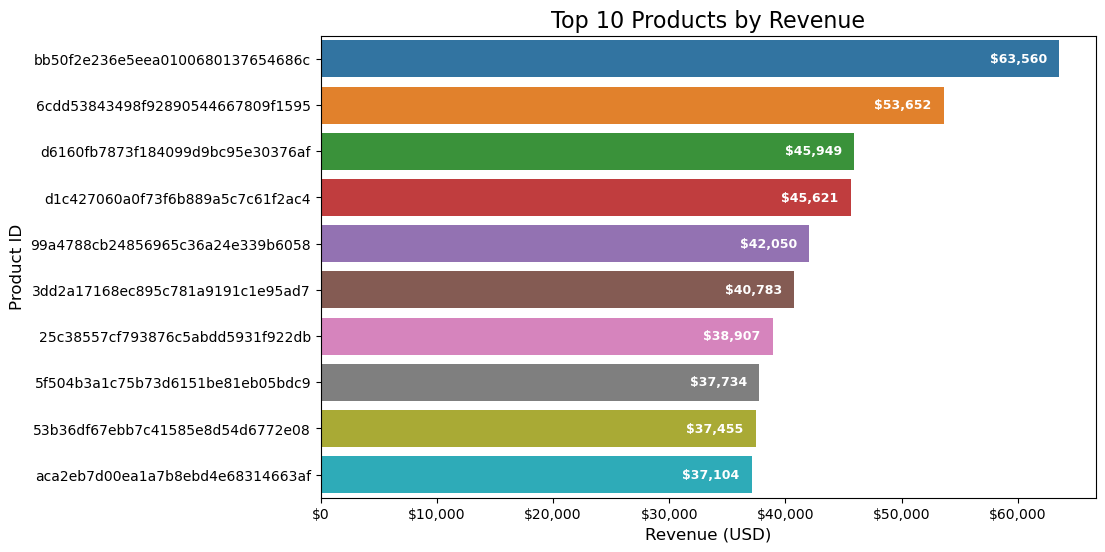

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x="total_revenue",
    y="product_id",
    data=top_products_revenue,
    ax=ax
)

# Add labels inside bars
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in top_products_revenue["total_revenue"]],
        padding=-50,
        color='white',
        fontsize=9,
        fontweight='bold'
    )

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Titles
ax.set_title("Top 10 Products by Revenue", fontsize=16)
ax.set_xlabel("Revenue (USD)", fontsize=12)
ax.set_ylabel("Product ID", fontsize=12)

plt.show()

### Product by units sold

In [42]:
top_products_sold = (
    product_summary
    .sort_values(by="total_orders", ascending=False)
    .head(10)
)
top_products_sold

,product_id,total_orders,total_revenue
21617,aca2eb7d00ea1a7b8ebd4e68314663af,520,37104.30
8429,422879e10f46682990de24d770e7f83d,484,26577.22
19290,99a4788cb24856965c36a24e339b6058,477,42049.66
7206,389d119b48cf3043d311335e499d9c6b,390,21336.79
6926,368c6c730842d78016ad823897a372db,388,21056.80
10589,53759a2ecddad2bb87a079a1f1519f73,373,20387.20
26436,d1c427060a0f73f6b889a5c7c61f2ac4,332,45620.56
10616,53b36df67ebb7c41585e8d54d6772e08,321,37454.63
2734,154e7e31ebfa092203795c972e5804a6,274,6173.26
7881,3dd2a17168ec895c781a9191c1e95ad7,272,40782.80


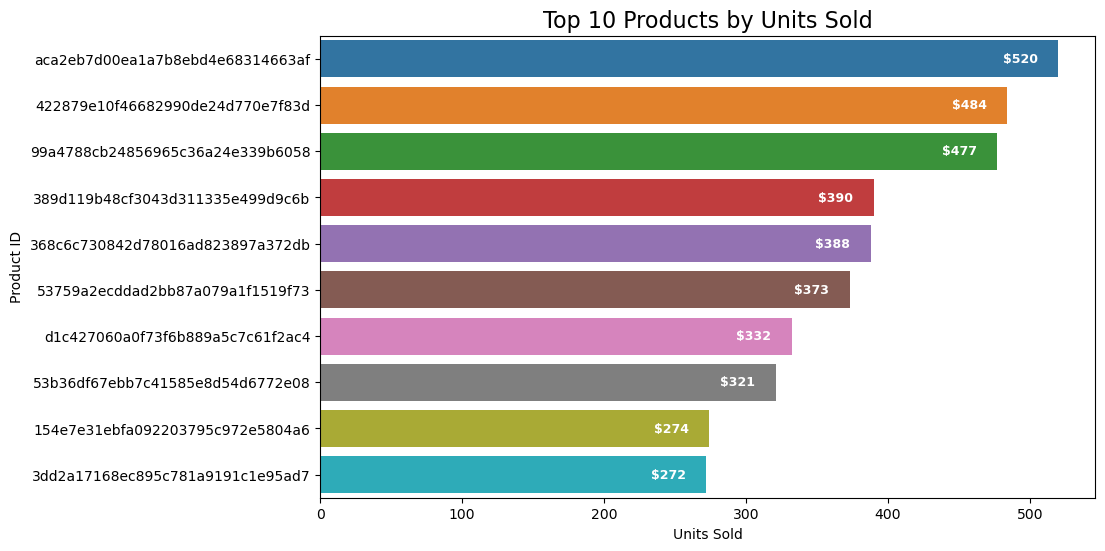

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x="total_orders",
    y="product_id",
    data=top_products_sold,
    ax=ax
)

# Add labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in top_products_sold["total_orders"]],
        label_type='edge',
        padding=-40,
        color='white',
        fontsize=9,
        fontweight='bold'
    )

# Titles
ax.set_title("Top 10 Products by Units Sold", fontsize=16)
ax.set_xlabel("Units Sold")
ax.set_ylabel("Product ID")

plt.show()

### Product Performance Analysis

**Objective:**  
To identify top-performing products based on revenue and sales volume, and understand their impact on customer behavior.

**Methodology:**  
- Aggregated data by product_id.
- Calculated:
  - Total Revenue (SUM of price)
  - Total Units Sold (COUNT of orders)
- Ranked top products by revenue and units sold.
- Compared overlapping products across both rankings.

**Key Insights:**  
- Several products appear in both top revenue and top sales lists, indicating strong overall performance.
- Some products generate high revenue with low sales volume, indicating high-priced items.
- Other products have high sales volume but lower revenue, indicating low-cost, frequently purchased items.

**Interpretation:**  
- High-revenue, low-volume products are likely one-time purchases.
- High-volume, low-revenue products are likely repeat purchase items.
- This explains why repeat customers have lower average order value.

**Business Implications:**  
- The business relies on expensive one-time purchases for revenue.
- Repeat purchases are driven by lower-value products.
- There is an opportunity to:
  - Bundle products
  - Recommend complementary items
  - Encourage repeat purchases of high-value products

**Visualization Notes:**  
- Horizontal bar charts improve readability for product IDs.
- Labels display formatted revenue and units sold.
- Consistent styling ensures clarity across analyses.

### Revenue VS Units sold

In [44]:
product_full = pd.merge(
    products,
    pcnt,
    on="product_category_name"
)

product_full = product_full.rename(columns={"product_category_name_english": "product_category"})
product_full["product_category"] = product_full["product_category"].str.strip().str.replace("_", " ").str.capitalize()
product_full = product_full.drop(columns=["product_category_name"])

product_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32328 entries, 0 to 32327
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32328 non-null  object 
 1   product_name_length         32328 non-null  float64
 2   product_description_length  32328 non-null  float64
 3   product_photos_qty          32328 non-null  int64  
 4   product_weight_g            32327 non-null  float64
 5   product_length_cm           32327 non-null  float64
 6   product_height_cm           32327 non-null  float64
 7   product_width_cm            32327 non-null  float64
 8   product_category            32328 non-null  object 
dtypes: float64(6), int64(1), object(2)
memory usage: 2.2+ MB


NameError: name 'high_revenue_high_demand' is not defined

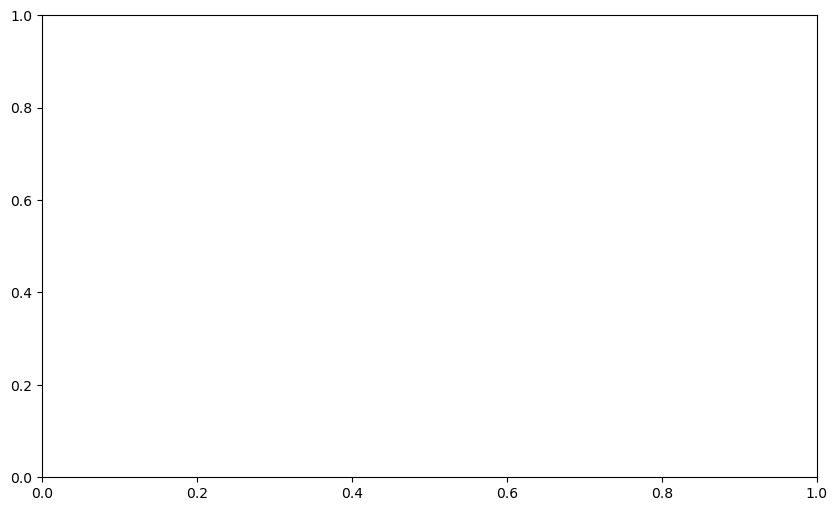

In [45]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# First axis (Revenue)
sns.barplot(
    x="product_id",
    y="total_revenue",
    data=high_revenue_high_demand,
    ax=ax1
)

ax1.set_ylabel("Revenue (USD)")
ax1.set_xlabel("Product ID")

ax1.yaxis.set_major_locator(MultipleLocator(5000))

# Second axis (Units Sold)
ax2 = ax1.twinx()

sns.lineplot(
    x="product_id",
    y="total_orders",
    data=high_revenue_high_demand,
    ax=ax2,
    marker="o"
)


ax2.set_ylabel("Units Sold")

# Rotate labels
ax1.tick_params(axis='x', rotation=90)

ax1.set_title("Revenue and Units Sold (Dual Axis)")

plt.show()

### High Revenue High Demand

In [ ]:
high_revenue_high_demand = pd.merge(
    top_products_revenue[["product_id", "total_revenue", "total_orders"]],
    top_products_sold[["product_id"]],
    on="product_id"
)

high_revenue_high_demand = pd.merge(
    high_revenue_high_demand[["product_id", "total_revenue", "total_orders"]],
    product_full[["product_id", "product_category"]],
    on="product_id")


high_revenue_high_demand

### Revenue vs Units Sold Visualization

**Objective:**  
To compare product performance (revenue) and demand (units sold) in a single view.

**Methodology:**  
- Used dual-axis visualization:
  - Bar chart for total revenue
  - Line chart for units sold
- Created a secondary axis using `twinx()` to handle different scales.

**Key Insights:**  
- Products with high revenue and high units sold are top performers.
- Products with high revenue but low units are expensive items.
- Products with high units but lower revenue are frequently purchased low-cost items.

**Interpretation:**  
- Dual-axis visualization allows comparison of two different metrics without distortion.
- Helps identify product positioning (premium vs volume-driven).

**Visualization Notes:**  
- Bars represent revenue (left axis).
- Line represents units sold (right axis).
- Rotation applied for readability of product IDs.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x="total_revenue",
    y="product_id",
    data=high_revenue_high_demand,
    ax=ax
)

# Add numeric labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=high_revenue_high_demand["product_category"],
        label_type='center',
        color='white',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title("High Revenue & High Demand Products")
ax.set_xlabel("Revenue (USD)")
ax.set_ylabel("Product & Category")

plt.show()

### High Revenue & High Demand Products

**Objective:**  
Identify products that generate high revenue *and* have high customer demand.

**Methodology:**  
- Merged `products` table with `product category` table to get English category names.
- Filtered top products by revenue (`top_products_revenue`).
- Further filtered to include only products that also have high sales volume (`top_products_units`).

**Key Insights:**  
- These products are the most valuable to the business because they:
  - Generate high revenue
  - Are frequently purchased
- They often appear in both top revenue and top units sold lists.

**Business Implications:**  
- Prioritize stock management for these products.
- Feature them in marketing campaigns.
- Consider bundling or upselling with complementary items.

**SQL Equivalent:**  

```sql
SELECT r.product_id, r.total_revenue, f.product_category_name_english, u.total_units_sold
FROM top_products_revenue r
JOIN product_full f
    ON r.product_id = f.product_id
JOIN top_products_units u
    ON r.product_id = u.product_id
ORDER BY r.total_revenue DESC, u.total_units_sold DESC;

### PRODUCT SEGMENTATION (Quadrant Analysis)

In [ ]:
revenue_threshold = product_summary["total_revenue"].mean()
units_threshold = product_summary["total_orders"].mean()

def segment(row):
    if row["total_revenue"] >= revenue_threshold and row["total_orders"] >= units_threshold:
        return "High Value & High Demand"
    elif row["total_revenue"] >= revenue_threshold:
        return "High Value & Low Demand"
    elif row["total_orders"] >= units_threshold:
        return "Low Value & High Demand"
    else:
        return "Low Value & Low Demand"

product_summary["segment"] = product_summary.apply(segment, axis=1)

In [ ]:
print(f"Revenue Threshold: {revenue_threshold}\nOrder Threshold: {units_threshold}")

In [ ]:
palette = {
    "High Value & High Demand": "green",
    "High Value & Low Demand": "orange",
    "Low Value & High Demand": "blue",
    "Low Value & Low Demand": "red"
}

fig, ax = plt.subplots(figsize=(8,6))

sns.scatterplot(
    data=product_summary,
    x="total_revenue",
    y="total_orders",
    hue="segment",
    palette=palette,
    s=50,                 # Size of the dots
    alpha=1,               # Transparency of the dots
    ax=ax
)

ax.legend(title="Segment", bbox_to_anchor=(1.05, 1), loc="upper left")

ax.axvline(revenue_threshold, linestyle="--")
ax.axhline(units_threshold, linestyle="--")

ax.yaxis.set_major_locator(MultipleLocator(50))

ax.set_title("Product Segmentation")
ax.set_xlabel("Total Revenue")
ax.set_ylabel("Total Unit Sold")

plt.show()

### Product Segmentation Analysis

**Objective:**  
To classify products based on revenue and demand performance.

**Methodology:**  
- Aggregated product-level data to compute total orders and total revenue.
- Used average thresholds for both metrics.
- Segmented products into four categories:
  - High Value & High Demand
  - High Value & Low Demand
  - Low Value & High Demand
  - Low Value & Low Demand

**Key Insights:**  
- High Value & High Demand products are top-performing and should be prioritized.
- High Value & Low Demand products may require marketing or pricing adjustments.
- Low Value & High Demand products indicate strong demand but lower pricing.
- Low Value & Low Demand products are underperforming.

**Visualization Notes:**  
- Scatter plot used to display product distribution.
- Quadrant lines represent average thresholds.
- Color coding enhances segmentation clarity.

#

## Category-Level Analysis

In [ ]:
category_summary = pd.merge(
    merged_orders[["product_id", "price"]],
    product_full[["product_id", "product_category"]],
    on="product_id")

In [ ]:
category_summary = category_summary.groupby("product_category").agg(
    total_revenue=("price", "sum"),
    total_products=("product_id", "count")
).reset_index().sort_values(by="total_revenue", ascending=False)

In [ ]:
category_summary["rank"] = (
    category_summary["total_revenue"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

In [ ]:
category_summary.head()

In [ ]:
category_summary["product_category"].unique()

In [ ]:
category_summary["product_category"].nunique()

In [ ]:
top_categories = category_summary.head(10)

# Create labels with revenue included
labels = [
    f"{cat}\n{rank}\n${rev:,.0f}"
    for cat, rank, rev in zip(
        top_categories["product_category"],
        top_categories["rank"],
        top_categories["total_revenue"]
    )
]

fig, ax = plt.subplots(figsize=(10,6))

squarify.plot(
    sizes=top_categories["total_revenue"],
    label=labels,
    alpha=0.85,
    text_kwargs={"color": "white", "fontsize": 9, "weight": "bold"},
    ax=ax
)

ax.set_title("Top 10 Categories by Revenue (Rank)", fontsize=14)
ax.axis("off")

plt.show()

### Treemap with Revenue Labels

**Objective:**  
To enhance treemap visualization by adding revenue values directly inside category labels.

**Methodology:**  
- Created custom labels combining category name and revenue.
- Formatted revenue values with thousand separators for readability.
- Applied white bold text styling for clarity on colored backgrounds.

**Key Improvements:**
- Each block now displays both category name and revenue.
- Improved readability through structured multi-line labels.
- Enhanced visual hierarchy using color intensity and size.

**Business Insight:**
- Enables quick identification of high-revenue categories.
- Combines proportional and numerical insights in a single view.

# 🧠 KEY BUSINESS INSIGHTS

## 🟢 1. Revenue Leaders (Money Drivers 💰)

Top categories:

* Health & Beauty → 1.23M
* Watches & Gifts → 1.16M
* Bed Bath Table → 1.02M

👉 Insight:
These categories are the **core revenue engine** of the business.

✔ Likely:

* High pricing strategy
* Strong brand demand
* Repeat purchases

---

## 📦 2. Demand Leaders (Volume Drivers)

Top by products:

* Bed Bath Table → 10,953 units
* Health Beauty → 9,465 units
* Sports Leisure → 8,431 units

👉 Insight:
These categories are **high-volume movers**

✔ They:

* Drive traffic
* Increase logistics pressure
* Require inventory planning

---

## ⚖️ 3. Balanced Performers (Best Categories)

👉 These perform well in BOTH:

* Health Beauty
* Bed Bath Table
* Sports Leisure

👉 Insight:
These are **strategic categories**
✔ Must be prioritized in:

* Marketing
* Stock planning
* Promotions

---

## 💡 4. Interesting Pattern (Very Important)

👉 Not all high-revenue categories have highest product count

Example:

* Watches & Gifts → high revenue but lower volume than Bed Bath Table

👉 Meaning:

* Higher **average product value**
* Premium category behavior 💎

---

### Category Segmentation

In [ ]:
revenue_threshold = category_summary["total_revenue"].mean()
demand_threshold = category_summary["total_products"].mean()

def segment(row):
    if row["total_revenue"] >= revenue_threshold and row["total_products"] >= demand_threshold:
        return "High Value & High Demand"
    elif row["total_revenue"] >= revenue_threshold:
        return "High Value & Low Demand"
    elif row["total_products"] >= demand_threshold:
        return "Low Value & High Demand"
    else:
        return "Low Value & Low Demand"

category_summary["segment"] = category_summary.apply(segment, axis=1)
category_summary

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

sns.scatterplot(
    data=category_summary,
    x="total_revenue",
    y="total_products",
    hue="segment",
    palette=palette,
    ax=ax
)

for _, row in category_summary.iterrows():
    ax.text(
        row["total_revenue"],
        row["total_products"],
        row["product_category"],
        fontsize=10
    )

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax.axvline(revenue_threshold, linestyle="--")
ax.axhline(demand_threshold, linestyle="--")

ax.set_title("Category Segmentation")
ax.legend(title="Segment", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

### Category Segmentation Analysis

**Objective:**  
To classify product categories based on revenue contribution and demand.

**Methodology:**  
- Calculated total revenue and total products per category.
- Used mean thresholds to define segmentation boundaries.
- Applied rule-based classification into four segments.

**Segments:**
- High Value & High Demand → Core business drivers
- High Value & Low Demand → Premium categories
- Low Value & High Demand → Volume-driven categories
- Low Value & Low Demand → Underperforming categories

**Visualization:**
- Scatter plot used to represent category positioning.
- Quadrant lines added using mean thresholds.
- Legend placed outside for clarity.

**Business Impact:**
- Enables strategic decision-making on inventory, pricing, and marketing.

In [ ]:
category_summary["AOV"] = round(category_summary["total_revenue"] / category_summary["total_products"])

In [ ]:
top_aov = category_summary.sort_values("AOV", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=top_aov,
    x="AOV",
    y="product_category",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        label=(category_summary["AOV"]),
        color="white",
        padding=-50,
        fontweight="bold"
    )

ax.set_title("Top Categories by Average Order Value (AOV)")
ax.set_xlabel("AOV (USD)")
ax.set_ylabel("Category")

plt.show()

In [ ]:
top_aov

###

## Customer RFM Analysis

# 📊 RFM Model (Customer Segmentation)

## 📌 What is RFM?

**RFM stands for:**

- **R → Recency**
- **F → Frequency**
- **M → Monetary**

It is a customer segmentation technique used in **Marketing Analytics** and **customer behavior analysis** to understand how valuable a customer is based on their purchasing activity.

---

# 🧠 RFM Explained Simply

## 📅 1. Recency (R)

👉 How recently a customer made a purchase

- More recent = more engaged customer  
- Less recent = at risk of churn  

### 📌 Example:
- Customer A bought yesterday → High Recency score  
- Customer B bought 6 months ago → Low Recency score  

---

## 🔁 2. Frequency (F)

👉 How often a customer buys

- High frequency = loyal customer  
- Low frequency = occasional buyer  

### 📌 Example:
- 10 orders in a year → High Frequency  
- 1 order in a year → Low Frequency  

---

## 💰 3. Monetary (M)

👉 How much money a customer spends

- High spenders = high value customers  
- Low spenders = low value customers  

### 📌 Example:
- $5,000 spent → High Monetary value  
- $50 spent → Low Monetary value  

In [ ]:
# Create customer rfm table

rfm = merged_orders.groupby("customer_id").agg(
    last_purchase_date=("order_purchase_timestamp", "max"),
    frequency=("order_id", "count"),
    monetary=("price", "sum")
).reset_index()

rfm.head()

In [ ]:
# Create Recency and add it to rfm table

# The last date in the dataset, single date. it could be today if data is recent
snapshot_date = merged_orders["order_purchase_timestamp"].max()

# Get the difference btw the last date in the dataset and the last date a customer purchas
rfm["recency"] = (snapshot_date - rfm["last_purchase_date"]).dt.days

In [ ]:
rfm["r_score"] = pd.qcut(rfm["recency"], 5, labels=[5,4,3,2,1])
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["m_score"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5])

# 📊 RFM Scoring Notes

---

## 🔹 Ranking with `rank()`

```python
frequency.rank(method="first")
````

### 🧠 Meaning:

* Assigns a **unique rank** to each value
* Prevents duplicate ranking issues

### 💡 Why `method="first"`?

* If two values are the same, ranking is assigned based on **order of appearance**
* Ensures **no ties (duplicates)** in ranking

---

## 🔹 Reversed Labels in Scoring

```python
labels=[5,4,3,2,1]
```

### 🧠 Why reversed labels (5 → 1)?

Because:

* **Low recency = GOOD** (customer purchased recently)
* **High recency = BAD** (customer inactive for long)

### 🔁 So we flip the score:

* Best customers → **5**
* Worst customers → **1**

---

## 🔹 Monetary Scoring with `qcut()`

```python
rfm["m_score"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5])
```

### 🧠 Meaning:

* Splits customers into **5 equal groups (quintiles)** based on spending

## 🔥 Summary

* `rank(method="first")` → avoids duplicate rankings
* `labels=[5,4,3,2,1]` → used when **lower value is better** (e.g. recency)
* `qcut()` → divides data into **equal-sized groups**
* Monetary score → higher spending = higher score

---

In [ ]:
rfm["rfm_score"] = (
    rfm["r_score"].astype(str) +
    rfm["f_score"].astype(str) +
    rfm["m_score"].astype(str)
)

In [ ]:
def segment_customer(row):
    if row["rfm_score"] == "555":
        return "Champions"
    elif row["f_score"] >= 4:
        return "Loyal Customers"
    elif row["r_score"] >= 4:
        return "Potential Loyalists"
    elif row["r_score"] <= 2:
        return "At Risk"
    else:
        return "Regular Customers"

rfm["segment"] = rfm.apply(segment_customer, axis=1)

rfm.head()

In [ ]:
segment_palette = {
    "Champions": "green",
    "Loyal Customers": "orange",
    "Potential Loyalists": "grey",
    "Regular Customers": "blue",
    "At Risk": "red"
}

segment_counts = rfm["segment"].value_counts()

colors = [segment_palette.get(label, "gray") for label in segment_counts.index]

fig, ax = plt.subplots(figsize=(7,7))

wedges, texts, autotexts = ax.pie(
    segment_counts.values,
    labels=segment_counts.index,   # Segment names
    colors=colors,
    autopct="%1.1f%%",             # Percentages
    startangle=140,
    labeldistance=1.1,
    pctdistance=0.7
)

# Style segment labels (outside)
for text in texts:
    text.set_color("black")
    text.set_fontsize(11)

# Style percentages (inside slices)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(11)
    autotext.set_weight("bold")

ax.set_title("Customer Segments (RFM Analysis)", fontsize=14)

plt.tight_layout()
plt.show()

In [32]:
rfm.to_csv("../data/cleaned/rfm.csv", index=False)

### Pie Chart Styling (Text Color Customization)

**Objective:**  
To improve readability of percentage values in RFM segmentation pie chart.

**Methodology:**  
- Applied `textprops` parameter to control text appearance inside pie chart.
- Set text color to white for better contrast against segment colors.
- Adjusted font size for clarity.

**Technical Insight:**
- `textprops` affects autopct labels and inner text in Matplotlib pie charts.
- White text improves visibility on dark-colored segments.

**Business Impact:**
- Enhances readability of visual insights.
- Improves presentation quality for reports and dashboards.

###

## Review Analysis

In [46]:
len(order_reviews)

98408

In [47]:
df = order_reviews.copy()

In [48]:
df = df.dropna(subset=["review_comment_message"])
df = df[df["review_comment_message"].str.strip() != ""]

In [49]:
len(df)

40639

In [50]:
df["review_score"].value_counts().sort_index()

review_score
1     8639
2     2118
3     3528
4     5935
5    20419
Name: count, dtype: int64

In [51]:
df["review_length"] = df["review_comment_message"].str.len()
df.groupby("review_score")["review_length"].mean()

review_score
1    99.986804
2    97.134561
3    83.285714
4    61.793766
5    51.913512
Name: review_length, dtype: float64

In [52]:
df_negative = df[df["review_score"] <= 2]
len(df_negative)

10757

In [62]:
df_sample = df_negative.sample(500, random_state=42)

In [63]:
len(df_sample)

500

In [70]:
translated = []

for x, text in enumerate(df_sample["review_comment_message"]):
    try:
        translated.append(translator.translate(text))
    except:
        translated.append(text)
    
    if x % 20 == 0:
        print(f"{x} rows processed")

0 rows processed
20 rows processed
40 rows processed
60 rows processed
80 rows processed
100 rows processed
120 rows processed
140 rows processed
160 rows processed
180 rows processed
200 rows processed
220 rows processed
240 rows processed
260 rows processed
280 rows processed
300 rows processed
320 rows processed
340 rows processed
360 rows processed
380 rows processed
400 rows processed
420 rows processed
440 rows processed
460 rows processed
480 rows processed


In [78]:
df_sample["review_en"] = translated

In [79]:
df_sample = df_sample.drop(columns=["review_comment_title", "review_comment_message"])

KeyError: "['review_comment_title', 'review_comment_message'] not found in axis"

In [74]:
df_sample["review_score"].value_counts().sort_index()

review_score
1    410
2     90
Name: count, dtype: int64

In [76]:
text = " ".join(df_sample["review_en"].str.lower())
words = text.split()

word_freq = Counter(words).most_common(15)
word_freq

[('o', 379),
 ('não', 326),
 ('e', 268),
 ('produto', 256),
 ('a', 230),
 ('de', 228),
 ('que', 181),
 ('recebi', 123),
 ('do', 112),
 ('com', 97),
 ('no', 96),
 ('um', 96),
 ('foi', 82),
 ('da', 77),
 ('para', 73)]

In [ ]:
words, counts = zip(*word_freq)

fig, ax = plt.subplots(figsize=(10,5))

sns.barplot(x=list(words), y=list(counts), ax=ax)

ax.set_title("Top Complaint Words")
ax.set_xlabel("Words")
ax.set_ylabel("Frequency")
ax.tick_params(axis='x', rotation=45)

plt.show()

In [ ]:
sia = SentimentIntensityAnalyzer()

df_sample["sentiment_score"] = df_sample["review_en"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

In [ ]:
sia = SentimentIntensityAnalyzer()

df_sample["sentiment_score"] = df_sample["review_en"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

In [ ]:

fig, ax = plt.subplots()

sns.countplot(x="sentiment", data=df_sample, ax=ax)

ax.set_title("Sentiment Distribution")

plt.show()

In [ ]:
## Compare Score vs Sentiment (Key Insight)
pd.crosstab(df_sample["review_score"], df_sample["sentiment"])